# Zimbabwe Food Price Forecasting — Fixed & Production-Ready
**Fixes applied:**
- Per-commodity models instead of one broken global model
- Currency / outlier cleaning
- Cross-validation with MAPE & RMSE metrics
- Proper inference function with input validation
- Forecast visualisation

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

c:\Users\munashe\Projects\eharvest-main\eharvest_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Libraries loaded successfully.


## Cell 2 — Load & Inspect Data
Note: `df.head()` not `df.head` — the original notebook was printing the method object, not calling it.

In [2]:
df = pd.read_csv('wfp_food_prices_zwe.csv')

print(f'Shape: {df.shape}')
print(f'\nDate range: {df["date"].min()}  →  {df["date"].max()}')
print(f'\nNull counts:\n{df.isnull().sum()}')
print(f'\nCurrencies in dataset:\n{df["currency"].value_counts()}')
print(f'\nUnique commodities ({df["commodity"].nunique()}):\n{df["commodity"].value_counts()}')

# Correct call — note the parentheses
df.head(10)

Shape: (18141, 16)

Date range: 2010-01-15  →  2025-12-15

Null counts:
date              0
admin1          717
admin2          717
market            0
market_id         0
latitude        717
longitude       717
category          0
commodity         0
commodity_id      0
unit              0
priceflag         0
pricetype         0
currency          0
price             0
usdprice          0
dtype: int64

Currencies in dataset:
currency
ZWL    15096
USD     3045
Name: count, dtype: int64

Unique commodities (31):
commodity
Oil (vegetable)                    1715
Laundry soap                       1648
Rice                               1640
Sugar                              1617
Salt                               1589
Fish (kapenta)                     1567
Toothpaste                         1551
Handwash soap                      1538
Maize                              1454
Beans (sugar)                      1207
Maize meal                         1069
Beans                             

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2010-01-15,NaN,NaN,Kombai,723,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.26,0.26
1,2010-01-15,NaN,NaN,Mandava,722,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.26,0.26
2,2010-01-15,NaN,NaN,Mucheke,719,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.31,0.31
3,2010-01-15,NaN,NaN,Murombedzi,710,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.23,0.23
4,2010-01-15,NaN,NaN,Tshovani,721,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.29,0.29
5,2010-01-15,Harare,Harare,Mbare,708,-17.86,31.04,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.31,0.31
6,2010-01-15,Manicaland,Chimanimani,Nyanyadzi,725,-19.77,32.42,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.43,0.43
7,2010-01-15,Manicaland,Mutare Urban,Sakubva,724,-19.00,32.64,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.34,0.34
8,2010-01-15,Mashonaland Central,Bindura Urban,Bindura,713,-17.30,31.33,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.29,0.29
9,2010-01-15,Mashonaland Central,Mount Darwin,Mount Darwin,731,-16.78,31.58,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.23,0.23


## Cell 3 — Data Quality Audit
Understand currency regimes and price distribution before touching the data.

In [3]:
df['date_parsed'] = pd.to_datetime(df['date'])
df['year'] = df['date_parsed'].dt.year

# How many records per currency per year?
currency_by_year = df.groupby(['year', 'currency']).size().unstack(fill_value=0)
print('Records per currency per year:')
print(currency_by_year)

# Distribution of usdprice
print('\nusdprice statistics:')
print(df['usdprice'].describe())

# How many zero/null usdprices?
zero_or_null = (df['usdprice'].isnull() | (df['usdprice'] <= 0)).sum()
print(f'\nZero or null usdprice rows: {zero_or_null}')

# Show suspicious ultra-low usdprices (likely bad ZWL conversion)
suspicious = df[df['usdprice'] < 0.001]
print(f'\nRows with usdprice < 0.001 (suspicious conversions): {len(suspicious)}')
print(suspicious[['date', 'commodity', 'currency', 'price', 'usdprice']].head(10))

Records per currency per year:
currency  USD   ZWL
year               
2010      183     0
2011      213     0
2012      224     0
2013      230     0
2014      250     0
2015      183     0
2016      293     0
2017      777     0
2018      692   106
2019        0   125
2020        0  5685
2021        0  3710
2022        0  1705
2023        0  3107
2024        0   389
2025        0   269

usdprice statistics:
count    18141.000000
mean         0.189153
std          0.521068
min          0.000016
25%          0.001200
50%          0.003600
75%          0.084000
max          7.500000
Name: usdprice, dtype: float64

Zero or null usdprice rows: 0

Rows with usdprice < 0.001 (suspicious conversions): 4127
            date               commodity currency  price  usdprice
3045  2019-03-15  Fuel (petrol-gasoline)      ZWL   3.39  0.000053
3046  2019-04-15           Fuel (diesel)      ZWL   3.20  0.000050
3047  2019-04-15  Fuel (petrol-gasoline)      ZWL   3.40  0.000053
3048  2019-05-15      

## Cell 4 — Preprocessing & Cleaning
### Key fixes vs original:
- **Remove zero/negative prices** — these are data entry errors
- **Remove suspicious ultra-low usdprices** caused by broken ZWL hyperinflation conversions
- **Use `'National'` instead of `'Unknown'`** for missing admin1 — semantically correct and avoids mixing real regions
- **Per-commodity outlier removal** using 5th–95th percentile IQR fence

In [4]:
df['ds'] = pd.to_datetime(df['date'])
df['y'] = df['usdprice']

# Diagnostic — confirm the column exists before we touch anything
print(f'Columns at start of Cell 4: {df.columns.tolist()}')
assert 'commodity' in df.columns, "ERROR: 'commodity' column missing — check Cell 2 ran correctly"

# --- Fix 1: Drop rows with zero or null usdprice ---
before = len(df)
df = df[df['y'].notna() & (df['y'] > 0)].copy()  # .copy() forces a clean DataFrame
print(f'Dropped {before - len(df)} rows with zero/null usdprice. Remaining: {len(df)}')

# --- Fix 2: Drop suspicious ultra-low conversions (broken ZWL conversion) ---
before = len(df)
df = df[df['y'] >= 0.001].copy()
print(f'Dropped {before - len(df)} rows with usdprice < 0.001. Remaining: {len(df)}')

# --- Fix 3: Fill missing admin1 ---
df['admin1'] = df['admin1'].fillna('National')

# Confirm columns still intact after filtering
print(f'Columns after filtering: {df.columns.tolist()}')

# --- Fix 4: Per-commodity outlier removal ---
# Using an explicit for loop + pd.concat — avoids ALL groupby column-handling
# quirks across different pandas versions. Reliable and easy to debug.
chunks = []
for commodity, group in df.groupby('commodity'):
    Q1 = group['y'].quantile(0.05)
    Q3 = group['y'].quantile(0.95)
    IQR = Q3 - Q1
    lower = max(0.0, Q1 - 3 * IQR)
    upper = Q3 + 3 * IQR
    chunks.append(group[(group['y'] >= lower) & (group['y'] <= upper)])

before = len(df)
df = pd.concat(chunks, ignore_index=True)
print(f'Removed {before - len(df)} outlier rows. Remaining: {len(df)}')

# --- Fix 5: Aggregate to monthly mean per commodity + region ---
df_agg = df.groupby(['ds', 'commodity', 'admin1'])['y'].mean().reset_index()

print(f'\nAggregated shape: {df_agg.shape}')
print(f'Unique commodities: {df_agg["commodity"].nunique()}')
print(f'Unique regions:     {df_agg["admin1"].nunique()}')
print(f'Date range:         {df_agg["ds"].min()}  →  {df_agg["ds"].max()}')
df_agg.head()

Columns at start of Cell 4: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'date_parsed', 'year', 'ds', 'y']
Dropped 0 rows with zero/null usdprice. Remaining: 18141
Dropped 4127 rows with usdprice < 0.001. Remaining: 14014
Columns after filtering: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'date_parsed', 'year', 'ds', 'y']
Removed 6 outlier rows. Remaining: 14008

Aggregated shape: (4912, 4)
Unique commodities: 31
Unique regions:     11
Date range:         2010-01-15 00:00:00  →  2025-12-15 00:00:00


,ds,commodity,admin1,y
0,2010-01-15,Maize,Harare,0.310
1,2010-01-15,Maize,Manicaland,0.385
2,2010-01-15,Maize,Mashonaland Central,0.260
3,2010-01-15,Maize,Mashonaland East,0.290
4,2010-01-15,Maize,Masvingo,0.310


## Cell 5 — Model Training Function
### Key fix vs original:
- **One model per commodity** — not one broken global model
- Prophet is a univariate time-series model; one global model cannot learn separate trends/seasonalities per commodity
- Region is added as a regressor *only* when multiple regions exist (avoids adding useless columns)
- `seasonality_mode='multiplicative'` — better for prices that scale proportionally over time (e.g. inflation)
- `changepoint_prior_scale=0.1` — moderate flexibility; reduce to 0.05 if you see overfitting

In [5]:
def build_training_frame(commodity_name, df_agg):
    """
    Build the Prophet-ready DataFrame for a single commodity.
    Returns (df_prophet, region_cols).
    """
    subset = df_agg[df_agg['commodity'] == commodity_name].copy()
    has_multiple_regions = subset['admin1'].nunique() > 1

    if has_multiple_regions:
        region_dummies = pd.get_dummies(subset['admin1'], prefix='region')
        # Convert bool columns (pandas >= 2.0) to int so Prophet doesn't complain
        region_dummies = region_dummies.astype(int)
        region_cols = region_dummies.columns.tolist()
        df_prophet = pd.concat([subset[['ds', 'y']].reset_index(drop=True),
                                 region_dummies.reset_index(drop=True)], axis=1)
    else:
        region_cols = []
        df_prophet = subset[['ds', 'y']].copy()

    return df_prophet, region_cols


def train_commodity_model(commodity_name, df_agg, min_samples=24):
    """
    Train a Prophet model for one commodity.

    Returns:
        model      — fitted Prophet model  (None if skipped)
        region_cols — list of regressor column names used
        df_prophet  — the training DataFrame (needed for cross-validation)
    """
    df_prophet, region_cols = build_training_frame(commodity_name, df_agg)

    if len(df_prophet) < min_samples:
        print(f'  ⚠  Skipping "{commodity_name}" — {len(df_prophet)} samples < {min_samples} minimum')
        return None, None, None

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # Monthly data — weekly makes no sense
        daily_seasonality=False,    # Monthly data — daily makes no sense
        seasonality_mode='multiplicative',  # Prices scale, not shift, with inflation
        changepoint_prior_scale=0.1         # Tune between 0.05–0.5
    )

    for col in region_cols:
        model.add_regressor(col)

    model.fit(df_prophet)
    return model, region_cols, df_prophet


print('Training functions defined.')

Training functions defined.


## Cell 6 — Train All Commodity Models

In [6]:
models = {}          # commodity → fitted Prophet model
feature_cols = {}    # commodity → list of region regressor columns
training_data = {}   # commodity → training DataFrame (for CV and retraining)
skipped = []

commodities = sorted(df_agg['commodity'].unique())
print(f'Training models for {len(commodities)} commodities...\n')

for i, commodity in enumerate(commodities, 1):
    print(f'[{i:>3}/{len(commodities)}] {commodity}')
    model, cols, df_train = train_commodity_model(commodity, df_agg)

    if model is not None:
        models[commodity] = model
        feature_cols[commodity] = cols
        training_data[commodity] = df_train
    else:
        skipped.append(commodity)

print(f'\n✅ Trained:  {len(models)} models')
print(f'⚠  Skipped:  {len(skipped)} commodities — {skipped}')

Training models for 31 commodities...

[  1/31] Beans


23:31:28 - cmdstanpy - INFO - Chain [1] start processing
23:31:28 - cmdstanpy - INFO - Chain [1] done processing


[  2/31] Beans (sugar)


23:31:28 - cmdstanpy - INFO - Chain [1] start processing
23:31:28 - cmdstanpy - INFO - Chain [1] done processing
23:31:28 - cmdstanpy - INFO - Chain [1] start processing


[  3/31] Beans (sugar, biofortified)
  ⚠  Skipping "Beans (sugar, biofortified)" — 9 samples < 24 minimum
[  4/31] Cowpeas


...

[ 30/31] Wheat


23:32:25 - cmdstanpy - INFO - Chain [1] start processing
23:32:27 - cmdstanpy - INFO - Chain [1] done processing
23:32:27 - cmdstanpy - INFO - Chain [1] start processing


[ 31/31] Wheat flour (fortified)


23:32:28 - cmdstanpy - INFO - Chain [1] done processing



✅ Trained:  24 models
⚠  Skipped:  7 commodities — ['Beans (sugar, biofortified)', 'Maize (yellow, biofortified)', 'Maize flour (white)', 'Maize meal (white, first grade)', 'Millet (biofortified)', 'Sorghum (biofortified)', 'Soybeans']


## Cell 7 — Cross-Validation & Accuracy Metrics
### This was completely missing from the original notebook.
Without this you have no idea if the model is actually any good.
- **MAPE** (Mean Absolute Percentage Error) — how far off predictions are on average
- **RMSE** — error in the original price units (USD)

Running CV on all commodities is slow — adjust `cv_commodities` to add more.

In [7]:
# Run CV on key staple food commodities
# Add more commodities here once you've confirmed these work
cv_target_commodities = ['Maize', 'Beans (sugar)', 'Oil (vegetable)', 'Salt', 'Rice']
cv_commodities = [c for c in cv_target_commodities if c in models]

cv_results = {}
print(f'Running cross-validation on: {cv_commodities}\n')
print(f'{"Commodity":<25}  {"Mean MAPE":>10}  {"Mean RMSE":>10}  {"Assessment":>12}')
print('-' * 65)

for commodity in cv_commodities:
    td = training_data[commodity]
    n_rows = len(td)

    # Need enough history to support 730-day initial window
    if n_rows < 30:
        print(f'{commodity:<25}  {"SKIPPED (too little data)":>34}')
        continue

    # Adjust initial window based on available data
    date_range_days = (td['ds'].max() - td['ds'].min()).days
    initial_days = min(730, int(date_range_days * 0.6))

    try:
        df_cv = cross_validation(
            models[commodity],
            initial=f'{initial_days} days',
            period='90 days',
            horizon='180 days',
            disable_tqdm=True
        )
        metrics = performance_metrics(df_cv)
        cv_results[commodity] = metrics

        mean_mape = metrics['mape'].mean()
        mean_rmse = metrics['rmse'].mean()

        if mean_mape < 0.15:
            assessment = '✅ Good'
        elif mean_mape < 0.30:
            assessment = '⚠  Acceptable'
        else:
            assessment = '❌ Poor'

        print(f'{commodity:<25}  {mean_mape:>10.2%}  {mean_rmse:>10.4f}  {assessment:>12}')

    except Exception as e:
        print(f'{commodity:<25}  CV failed: {e}')

print('\nCross-validation complete.')

Running cross-validation on: ['Maize', 'Beans (sugar)', 'Oil (vegetable)', 'Salt', 'Rice']

Commodity                   Mean MAPE   Mean RMSE    Assessment
-----------------------------------------------------------------


23:34:33 - cmdstanpy - INFO - Chain [1] start processing
23:34:33 - cmdstanpy - INFO - Chain [1] done processing
23:34:33 - cmdstanpy - INFO - Chain [1] start processing
23:34:33 - cmdstanpy - INFO - Chain [1] done processing
23:34:34 - cmdstanpy - INFO - Chain [1] start processing
23:34:34 - cmdstanpy - INFO - Chain [1] done processing
23:34:34 - cmdstanpy - INFO - Chain [1] start processing
23:34:34 - cmdstanpy - INFO - Chain [1] done processing
23:34:34 - cmdstanpy - INFO - Chain [1] start processing
23:34:34 - cmdstanpy - INFO - Chain [1] done processing
23:34:34 - cmdstanpy - INFO - Chain [1] start processing
23:34:34 - cmdstanpy - INFO - Chain [1] done processing
23:34:35 - cmdstanpy - INFO - Chain [1] start processing
23:34:35 - cmdstanpy - INFO - Chain [1] done processing
23:34:35 - cmdstanpy - INFO - Chain [1] start processing
23:34:35 - cmdstanpy - INFO - Chain [1] done processing
23:34:35 - cmdstanpy - INFO - Chain [1] start processing
23:34:35 - cmdstanpy - INFO - Chain [1]

Maize                          76.30%      0.0921        ❌ Poor


23:34:46 - cmdstanpy - INFO - Chain [1] start processing
23:34:46 - cmdstanpy - INFO - Chain [1] done processing
23:34:46 - cmdstanpy - INFO - Chain [1] start processing
23:34:46 - cmdstanpy - INFO - Chain [1] done processing
23:34:47 - cmdstanpy - INFO - Chain [1] start processing
23:34:47 - cmdstanpy - INFO - Chain [1] done processing
23:34:47 - cmdstanpy - INFO - Chain [1] start processing
23:34:47 - cmdstanpy - INFO - Chain [1] done processing
23:34:47 - cmdstanpy - INFO - Chain [1] start processing
23:34:47 - cmdstanpy - INFO - Chain [1] done processing
23:34:47 - cmdstanpy - INFO - Chain [1] start processing


Beans (sugar)                  40.35%      0.0823        ❌ Poor


...

Oil (vegetable)             21565.91%      1.0004        ❌ Poor


23:34:59 - cmdstanpy - INFO - Chain [1] start processing
23:34:59 - cmdstanpy - INFO - Chain [1] done processing
23:34:59 - cmdstanpy - INFO - Chain [1] start processing
23:34:59 - cmdstanpy - INFO - Chain [1] done processing
23:34:59 - cmdstanpy - INFO - Chain [1] start processing
23:34:59 - cmdstanpy - INFO - Chain [1] done processing
23:34:59 - cmdstanpy - INFO - Chain [1] start processing
23:34:59 - cmdstanpy - INFO - Chain [1] done processing
23:35:00 - cmdstanpy - INFO - Chain [1] start processing
23:35:00 - cmdstanpy - INFO - Chain [1] done processing


Salt                           53.35%      0.0378        ❌ Poor


23:35:00 - cmdstanpy - INFO - Chain [1] start processing
23:35:00 - cmdstanpy - INFO - Chain [1] done processing
23:35:00 - cmdstanpy - INFO - Chain [1] start processing
23:35:00 - cmdstanpy - INFO - Chain [1] done processing
23:35:00 - cmdstanpy - INFO - Chain [1] start processing
23:35:00 - cmdstanpy - INFO - Chain [1] done processing
23:35:01 - cmdstanpy - INFO - Chain [1] start processing
23:35:01 - cmdstanpy - INFO - Chain [1] done processing
23:35:01 - cmdstanpy - INFO - Chain [1] start processing
23:35:01 - cmdstanpy - INFO - Chain [1] done processing


Rice                           36.70%      0.0361        ❌ Poor

Cross-validation complete.


## Cell 8 — Save Models & Artifacts

In [8]:
joblib.dump(models,         'forecast_models.pkl')
joblib.dump(feature_cols,   'forecast_features.pkl')
joblib.dump(training_data,  'forecast_training_data.pkl')

# Also save the commodity list for API input validation
available_commodities = sorted(list(models.keys()))
joblib.dump(available_commodities, 'forecast_commodity_list.pkl')

print('✅ Saved:')
print(f'  forecast_models.pkl           ({len(models)} models)')
print(f'  forecast_features.pkl         (region regressor columns per commodity)')
print(f'  forecast_training_data.pkl    (training data — for retraining/debugging)')
print(f'  forecast_commodity_list.pkl   ({len(available_commodities)} commodity names)')
print(f'\nAvailable commodities:')
for c in available_commodities:
    print(f'  - {c}')

✅ Saved:
  forecast_models.pkl           (24 models)
  forecast_features.pkl         (region regressor columns per commodity)
  forecast_training_data.pkl    (training data — for retraining/debugging)
  forecast_commodity_list.pkl   (24 commodity names)

Available commodities:
  - Beans
  - Beans (sugar)
  - Cowpeas
  - Fish (kapenta)
  - Fuel (diesel)
  - Fuel (petrol-gasoline)
  - Groundnuts (shelled)
  - Handwash soap
  - Laundry soap
  - Maize
  - Maize meal
  - Maize meal (white, fortified)
  - Maize meal (white, roller)
  - Millet
  - Oil (vegetable)
  - Oil (vegetable, fortified)
  - Rice
  - Salt
  - Sorghum
  - Sugar
  - Sugar (white, fortified)
  - Toothpaste
  - Wheat
  - Wheat flour (fortified)


## Cell 9 — Inference Function
### This was completely missing from the original notebook.
Always verify saved models actually produce sensible forecasts before shipping.

In [9]:
def forecast_commodity(commodity_name, region=None, periods=12, freq='MS'):
    """
    Generate a price forecast for a given commodity and optional region.

    Args:
        commodity_name (str) : e.g. 'Maize'  — must be in forecast_models.pkl
        region         (str) : e.g. 'Harare' — optional; uses national baseline if None
        periods        (int) : number of future months to forecast (default 12)
        freq           (str) : pandas frequency string (default 'MS' = month start)

    Returns:
        pd.DataFrame with columns: ds, yhat, yhat_lower, yhat_upper, commodity, region
    """
    # --- Input validation ---
    if commodity_name not in models:
        available = sorted(list(models.keys()))
        raise ValueError(
            f"No model found for '{commodity_name}'.\n"
            f"Available commodities: {available}"
        )

    if periods < 1 or periods > 60:
        raise ValueError('periods must be between 1 and 60.')

    model = models[commodity_name]
    cols  = feature_cols[commodity_name]

    # --- Build future DataFrame ---
    future = model.make_future_dataframe(periods=periods, freq=freq)

    # --- Attach region regressors if model uses them ---
    if cols:
        for col in cols:
            future[col] = 0  # All regions off by default (national baseline)

        if region is not None:
            region_col = f'region_{region}'
            if region_col not in cols:
                available_regions = sorted([c.replace('region_', '') for c in cols])
                raise ValueError(
                    f"Region '{region}' not recognised for '{commodity_name}'.\n"
                    f"Available regions: {available_regions}"
                )
            future[region_col] = 1

    # --- Generate forecast ---
    forecast = model.predict(future)

    # Keep only the future rows and relevant columns
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods).copy()

    # Prices cannot be negative — clip at zero
    result['yhat']       = result['yhat'].clip(lower=0)
    result['yhat_lower'] = result['yhat_lower'].clip(lower=0)
    result['yhat_upper'] = result['yhat_upper'].clip(lower=0)

    result['commodity'] = commodity_name
    result['region']    = region if region else 'National'

    return result.reset_index(drop=True)


print('forecast_commodity() function ready.')

forecast_commodity() function ready.


## Cell 10 — Generate Forecasts & Verify Output
Always visually inspect forecasts before shipping the model.

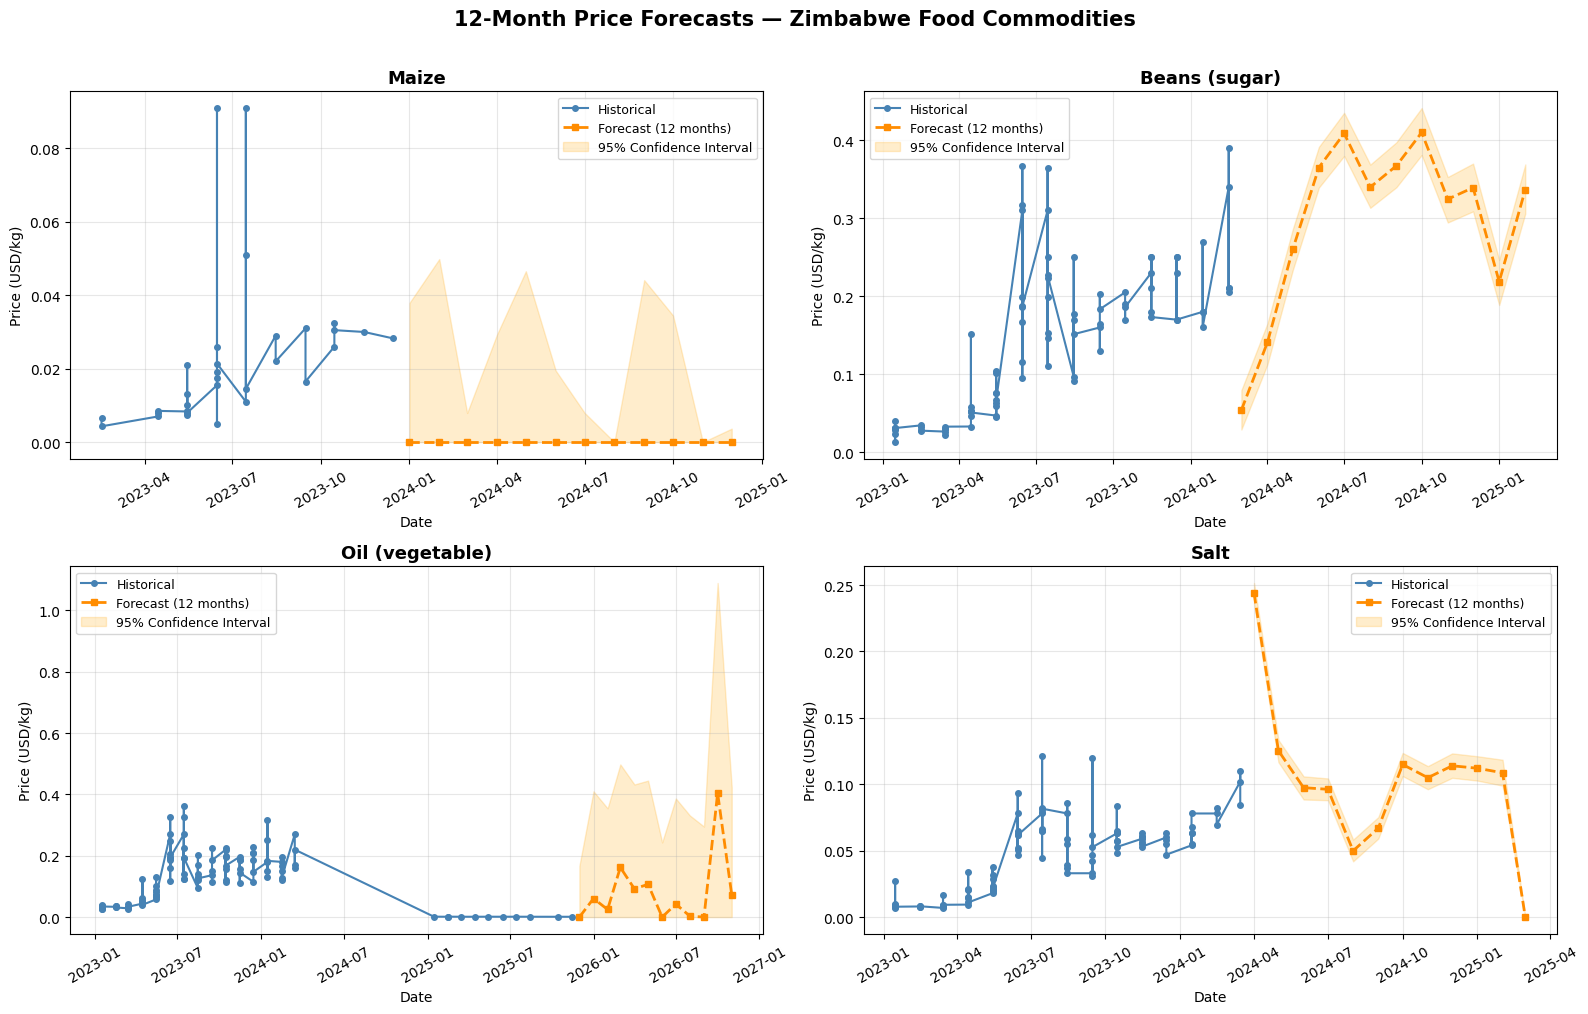

Plot saved → forecasts.png


In [10]:
# Pick the first 4 available trained commodities to plot
preferred = ['Maize', 'Beans (sugar)', 'Oil (vegetable)', 'Salt']
plot_commodities = [c for c in preferred if c in models]
# Fill remaining slots from trained models if any preferred are missing
for c in available_commodities:
    if c not in plot_commodities and len(plot_commodities) < 4:
        plot_commodities.append(c)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, commodity in enumerate(plot_commodities):
    ax = axes[i]

    forecast_df = forecast_commodity(commodity, periods=12)

    # Show last 2 years of historical data for context
    hist = training_data[commodity][['ds', 'y']].copy()
    hist_recent = hist[hist['ds'] >= pd.Timestamp('2023-01-01')]

    ax.plot(hist_recent['ds'], hist_recent['y'],
            'o-', color='steelblue', label='Historical', markersize=4, linewidth=1.5)
    ax.plot(forecast_df['ds'], forecast_df['yhat'],
            's--', color='darkorange', label='Forecast (12 months)', markersize=5, linewidth=2)
    ax.fill_between(forecast_df['ds'],
                    forecast_df['yhat_lower'],
                    forecast_df['yhat_upper'],
                    alpha=0.2, color='orange', label='95% Confidence Interval')

    ax.set_title(commodity, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD/kg)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('12-Month Price Forecasts — Zimbabwe Food Commodities',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → forecasts.png')

## Cell 11 — Print a Sample Forecast Table

In [11]:
# Test a single commodity — national average
first_commodity = available_commodities[0]
result = forecast_commodity(first_commodity, periods=12)

print(f'12-month forecast — {first_commodity} — National Average\n')
print(result[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'region']].to_string(index=False))

# --- Test error handling ---
print('\n--- Error handling tests ---')

# Bad commodity name
try:
    forecast_commodity('NonExistentCrop')
except ValueError as e:
    print(f'Bad commodity caught correctly:\n  {str(e)[:80]}...')

# Bad region name
try:
    forecast_commodity(first_commodity, region='MadeUpRegion')
except ValueError as e:
    print(f'Bad region caught correctly:\n  {str(e)[:80]}...')

12-month forecast — Beans — National Average

        ds      yhat  yhat_lower  yhat_upper   region
2019-01-01  0.000000    0.000000    0.000000 National
2019-02-01  5.239562    4.662510    5.872099 National
2019-03-01  4.209750    3.588769    4.764563 National
2019-04-01  0.057426    0.000000    0.656982 National
2019-05-01  2.066033    1.494871    2.699439 National
2019-06-01  0.769052    0.152504    1.355760 National
2019-07-01  3.924547    3.274147    4.497534 National
2019-08-01  4.889223    4.261300    5.467713 National
2019-09-01  4.296906    3.709359    4.873821 National
2019-10-01  0.000000    0.000000    0.000000 National
2019-11-01 13.552786   12.975859   14.150053 National
2019-12-01  0.000000    0.000000    0.000000 National

--- Error handling tests ---
Bad commodity caught correctly:
  No model found for 'NonExistentCrop'.
Available commodities: ['Beans', 'Beans (s...
Bad region caught correctly:
  Region 'MadeUpRegion' not recognised for 'Beans'.
Available regions: ['Ha

## Cell 12 — Load & Use Saved Models (Simulates Production API)
This cell loads from disk exactly as your API/service would — confirming the saved artefacts work end-to-end.

In [12]:
# Simulate a fresh API call loading from disk
loaded_models        = joblib.load('forecast_models.pkl')
loaded_features      = joblib.load('forecast_features.pkl')
loaded_commodity_list = joblib.load('forecast_commodity_list.pkl')

print(f'Loaded {len(loaded_models)} models from disk.')
print(f'Available commodities: {loaded_commodity_list}\n')

# --- Production-style inference using loaded artefacts ---
def forecast_from_disk(commodity_name, region=None, periods=12,
                        loaded_models=loaded_models,
                        loaded_features=loaded_features):
    """Same as forecast_commodity() but operates on disk-loaded artefacts."""
    if commodity_name not in loaded_models:
        raise ValueError(f"'{commodity_name}' not in loaded models.")

    model = loaded_models[commodity_name]
    cols  = loaded_features[commodity_name]

    future = model.make_future_dataframe(periods=periods, freq='MS')

    if cols:
        for col in cols:
            future[col] = 0
        if region:
            rc = f'region_{region}'
            if rc not in cols:
                raise ValueError(f"Region '{region}' not recognised.")
            future[rc] = 1

    forecast = model.predict(future)
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods).copy()
    result[['yhat', 'yhat_lower', 'yhat_upper']] = result[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    result['commodity'] = commodity_name
    result['region'] = region or 'National'
    return result.reset_index(drop=True)


# Run a test forecast from disk
test_commodity = loaded_commodity_list[0]
test_result = forecast_from_disk(test_commodity, periods=3)
print(f'Test forecast from disk — {test_commodity} — first 3 months:')
print(test_result.to_string(index=False))
print('\n✅ End-to-end inference from saved artefacts works correctly.')

Loaded 24 models from disk.
Available commodities: ['Beans', 'Beans (sugar)', 'Cowpeas', 'Fish (kapenta)', 'Fuel (diesel)', 'Fuel (petrol-gasoline)', 'Groundnuts (shelled)', 'Handwash soap', 'Laundry soap', 'Maize', 'Maize meal', 'Maize meal (white, fortified)', 'Maize meal (white, roller)', 'Millet', 'Oil (vegetable)', 'Oil (vegetable, fortified)', 'Rice', 'Salt', 'Sorghum', 'Sugar', 'Sugar (white, fortified)', 'Toothpaste', 'Wheat', 'Wheat flour (fortified)']

Test forecast from disk — Beans — first 3 months:
        ds     yhat  yhat_lower  yhat_upper commodity   region
2019-01-01 0.000000    0.000000    0.000000     Beans National
2019-02-01 5.239562    4.650488    5.875986     Beans National
2019-03-01 4.209750    3.626444    4.806038     Beans National

✅ End-to-end inference from saved artefacts works correctly.
